# 📝 Instrucciones
Prediciendo la diabetes
En los dos proyectos anteriores vimos cómo podíamos utilizar un árbol de decisión y después un random forest para mejorar la predicción de la diabetes. Hemos llegado a un punto en el que necesitamos mejorar. ¿Puede ser boosting la mejor de las alternativas para optimizar los resultados?

Boosting es una composición de modelos (generalmente árboles de decisión) secuencial en la cual el modelo nuevo persigue corregir los errores del anterior. Puede que esta visión nos sea útil en este conjunto de datos, ya que se cumplen varias de las suposiciones estudiadas en el módulo.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el 
accuracy
.

Recuerda que los proyectos anteriores puedes encontrarlos aquí (árboles de decisión) y aquí (random forest).

# Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

# Paso 2: Construye un boosting
Una forma de optimizar y mejorar los resultados es generar un boosting de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los hiperparámetros que definen al modelo con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

# Paso 3: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

# Paso 4: Analiza y compara los resultados de los modelos
Haz un estudio ahora de los tres modelos utilizados, analiza sus predicciones, la clase con más precisión de predicción y la que menos. ¿Con cuál de los tres modelos te quedas?



In [1]:
#importamos librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier

import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train_diabetes.csv")
X_test = pd.read_csv("../data/processed/X_test_diabetes.csv")

y_train = pd.read_csv("../data/processed/y_train_diabetes.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_diabetes.csv").values.ravel()

In [3]:
modelo_boosting  = HistGradientBoostingClassifier(random_state=42)
modelo_boosting.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [4]:
# Predicciones del modelo
y_pred_train = modelo_boosting.predict(X_train)
y_pred_test  = modelo_boosting.predict(X_test)

# Calculamos métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print('RESULTADOS DEL GRADIENT BOOSTING')
print('─' * 45)
print(f'  Accuracy en entrenamiento : {acc_train:.2%}')
print(f'  Accuracy en prueba        : {acc_test:.2%}')
print()

# Si la diferencia entre train y test es pequeña → buen modelo (no memoriza)
diferencia = acc_train - acc_test
print(f'  Diferencia train-test     : {diferencia:.2%}')
if diferencia < 0.05:
    print('  ✅ Diferencia pequeña → el modelo generaliza bien')
elif diferencia < 0.15:
    print('  ⚠️  Diferencia moderada → algo de sobreajuste')
else:
    print('  ❌ Diferencia grande → hay sobreajuste (overfitting)')

RESULTADOS DEL GRADIENT BOOSTING
─────────────────────────────────────────────
  Accuracy en entrenamiento : 100.00%
  Accuracy en prueba        : 74.68%

  Diferencia train-test     : 25.32%
  ❌ Diferencia grande → hay sobreajuste (overfitting)


In [5]:
# Reporte completo de métricas
print('REPORTE COMPLETO (datos de prueba):')
print(classification_report(
    y_test, y_pred_test,
    target_names=['No Diabético (0)', 'Diabético (1)']
))

REPORTE COMPLETO (datos de prueba):
                  precision    recall  f1-score   support

No Diabético (0)       0.80      0.82      0.81       100
   Diabético (1)       0.65      0.61      0.63        54

        accuracy                           0.75       154
       macro avg       0.72      0.72      0.72       154
    weighted avg       0.74      0.75      0.75       154



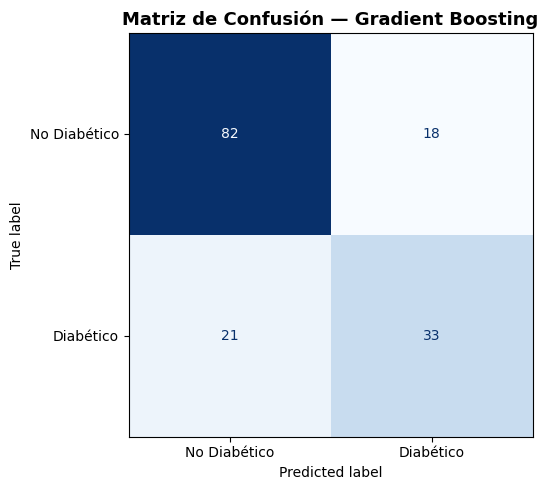

  ✅ Verdadero Negativo       : 82 Sanos predichos como sanos
  ❌ Falso Positivo  : 18  Sanos predichos como diabéticos
  ⚠️ Falso Negativo   : 21 → Diabéticos predichos como sanos (peor error)
  ✅ Verdadero Positivo :  33 Diabéticos predichos como diabéticos


In [6]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))

cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabético', 'Diabético'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de Confusión — Gradient Boosting', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Explicación
tn, fp, fn, tp = cm.ravel()
print(f'  ✅ Verdadero Negativo       : {tn} Sanos predichos como sanos')
print(f'  ❌ Falso Positivo  : {fp}  Sanos predichos como diabéticos')
print(f'  ⚠️ Falso Negativo   : {fn} → Diabéticos predichos como sanos (peor error)') 
print(f'  ✅ Verdadero Positivo :  {tp} Diabéticos predichos como diabéticos')

# Impacto en la modificaciones de los hiperparametros

## Impacto en n_estimators

In [7]:
n_rondas = [50, 100, 200, 300]
scores = []

for n in n_rondas:
    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    scores.append(accuracy_score(y_test, pred))

plt.plot(n_estimators, scores, marker='o')
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators")
plt.show()

NameError: name 'n_estimators' is not defined

El mejor numero de estimadores o rondas de correccion es de 100 y 200 

## Impacto en learning rate 

Este es el hiperparámetro más especial del Boosting.

Un valor alto (ej. 0.5) → aprende rápido pero puede equivocarse más
Un valor bajo (ej. 0.01) → aprende muy despacio, necesita más rondas

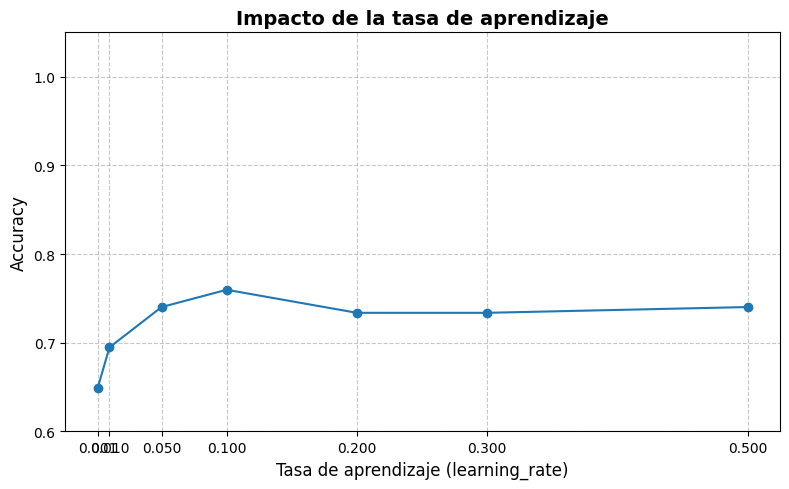

In [ ]:
tasas_aprendizaje = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
scores_lr = []

for lr in tasas_aprendizaje:
    modelo = GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                                        max_depth=3, random_state=42)
    modelo.fit(X_train, y_train)
scores_lr.append(accuracy_score(y_test,   modelo.predict(X_test)))


# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(tasas_aprendizaje, acc_test_lr, marker='o')
plt.xlabel('Tasa de aprendizaje (learning_rate)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Impacto de la tasa de aprendizaje', fontweight='bold', fontsize=14)
plt.xticks(tasas_aprendizaje)
plt.ylim(0.6, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


La mejor opción es el 0.1 para el modelo 

## Impacto en el max_depth

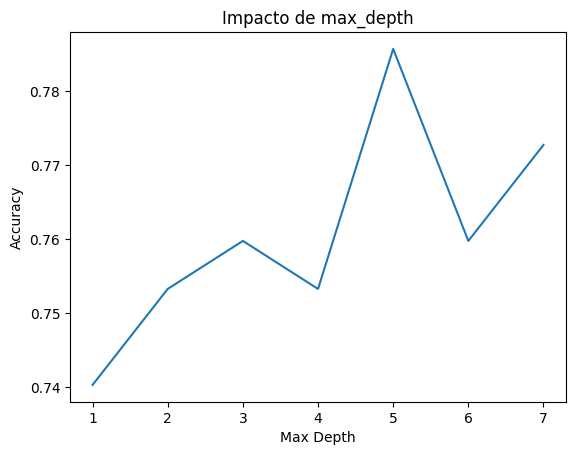

In [ ]:
max_depths = [1, 2, 3, 4, 5,6,7]
scores_depth = []
for depth in max_depths:
    model = HistGradientBoostingClassifier(
        max_depth= depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores_depth.append(accuracy_score(y_test, pred))
plt.plot(max_depths, scores_depth)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Impacto de max_depth")
plt.show()

Aqui nos indica que es mejor tener un max_depth de 5 pero informandome en internet, para boosting lo mejor o lo habitual es tener arboles pequeños.

# Guardamos el modelo 

In [ ]:
joblib.dump(modelo_boosting, '../models/boosting_model.pkl')

print('✅ Modelo guardado correctamente en: ../models/boosting_model.pkl')

✅ Modelo guardado correctamente en: ../models/boosting_model.pkl


# Comparación entre todos los modelos 


In [ ]:
# Creamos y entrenamos los tres modelos con sus mejores configuraciones conocidas

# Árbol de Decisión (del proyecto 1)
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)

# Random Forest (del proyecto 2 — con los parámetros que usaste)
random_forest = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
random_forest.fit(X_train, y_train)

# Gradient Boosting (este proyecto)
boosting = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                       max_depth=5, random_state=42)
boosting.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
# Función para calcular todas las métricas de un modelo de una sola vez
def metricas_completas(nombre, modelo, X_tr, y_tr, X_te, y_te):
    pred_tr = modelo.predict(X_tr)
    pred_te = modelo.predict(X_te)
    return {
        'Modelo'        : nombre,
        'Acc. Train'    : accuracy_score(y_tr, pred_tr),
        'Acc. Test'     : accuracy_score(y_te, pred_te),
        'Precision'     : precision_score(y_te, pred_te),
        'Recall'        : recall_score(y_te, pred_te),
        'F1-Score'      : f1_score(y_te, pred_te),
        'Overfit Gap'   : accuracy_score(y_tr, pred_tr) - accuracy_score(y_te, pred_te)
    }

# Calculamos métricas para los tres modelos
resultados = [
    metricas_completas('🌿 Árbol de Decisión', arbol,         X_train, y_train, X_test, y_test),
    metricas_completas('🌲 Random Forest',      random_forest, X_train, y_train, X_test, y_test),
    metricas_completas('🚀 Gradient Boosting',  boosting,      X_train, y_train, X_test, y_test),
]

# Tabla comparativa
tabla_final = pd.DataFrame(resultados).set_index('Modelo')

print('COMPARACIÓN FINAL DE LOS TRES MODELOS')
print(tabla_final.map(lambda x: f'{x:.4f}').to_string())

COMPARACIÓN FINAL DE LOS TRES MODELOS
                    Acc. Train Acc. Test Precision  Recall F1-Score Overfit Gap
Modelo                                                                         
🌿 Árbol de Decisión     1.0000    0.6818    0.5532  0.4815   0.5149      0.3182
🌲 Random Forest         1.0000    0.7792    0.7273  0.5926   0.6531      0.2208
🚀 Gradient Boosting     0.9984    0.7597    0.6809  0.5926   0.6337      0.2386


El mejor modelo es el random forest ya que tiene el mejor accuracy de los 3 